In [31]:
#!pip install osmnx

import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Configuração opcional para melhorar o uso de cache do OSMnx e log
# ox.config(log_console=True, use_cache=True)

In [32]:
# Insira a latitude e longitude do ponto central da sua análise
# -6.0636327,-35.2334585
LATITUDE = -6.0636327
LONGITUDE = -35.2334585
LABEL = "São José de Mipibu - RN"

DISTANCIA_METROS = 5000

In [33]:
centro = (LATITUDE, LONGITUDE)

G = ox.graph.graph_from_point(centro, dist=DISTANCIA_METROS, network_type='drive')
# G = ox.graph.graph_from_place("São José de Mipibu, Rio Grande do Norte, Brazil", network_type='drive')

print(f"Grafo da região '{LABEL}' gerado com sucesso!")

Grafo da região 'São José de Mipibu - RN' gerado com sucesso!


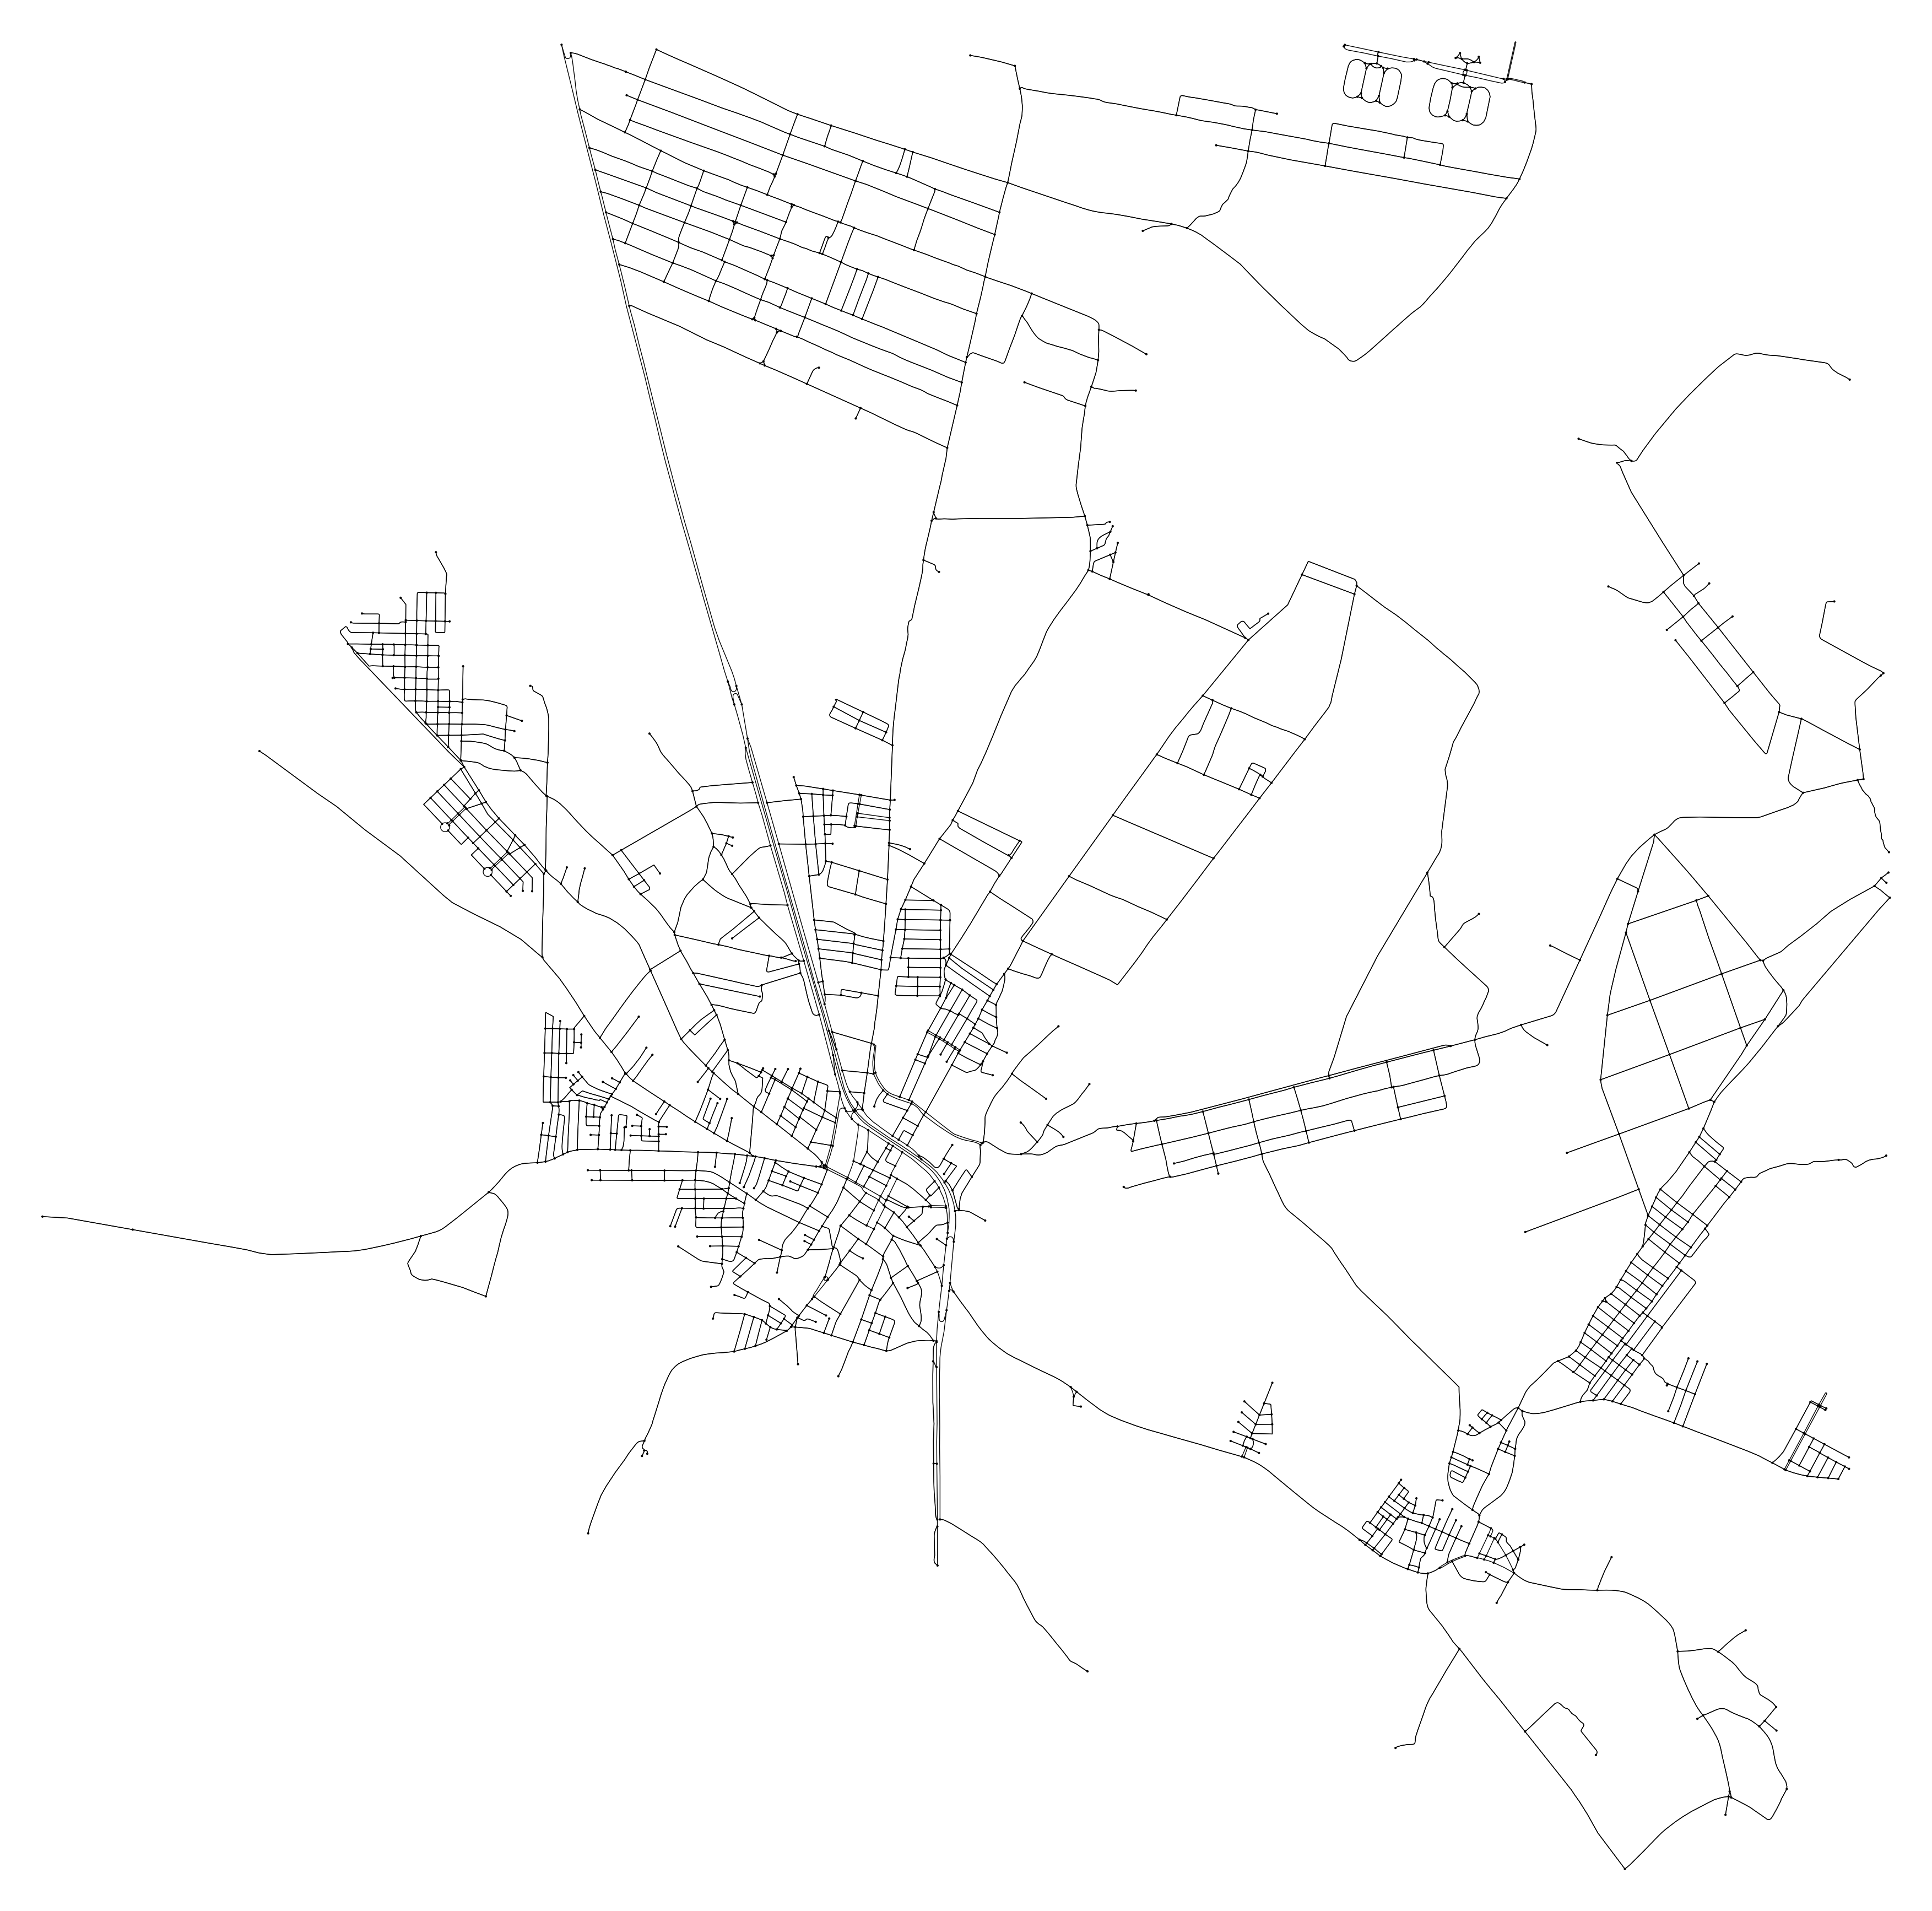

In [34]:
# Grafo limpo
fig, ax = ox.plot.plot_graph(G,
                             figsize=(45, 45),
                             node_size=9,
                             edge_linewidth=1.0,
                             bgcolor='white',
                             node_color='black',
                             edge_color='black'
                             )

Direção

Vias em VERMELHO são de mão única (fluxo direcionado assimétrico).
Vias em CINZA são de mão dupla (fluxo bidirecional simétrico).


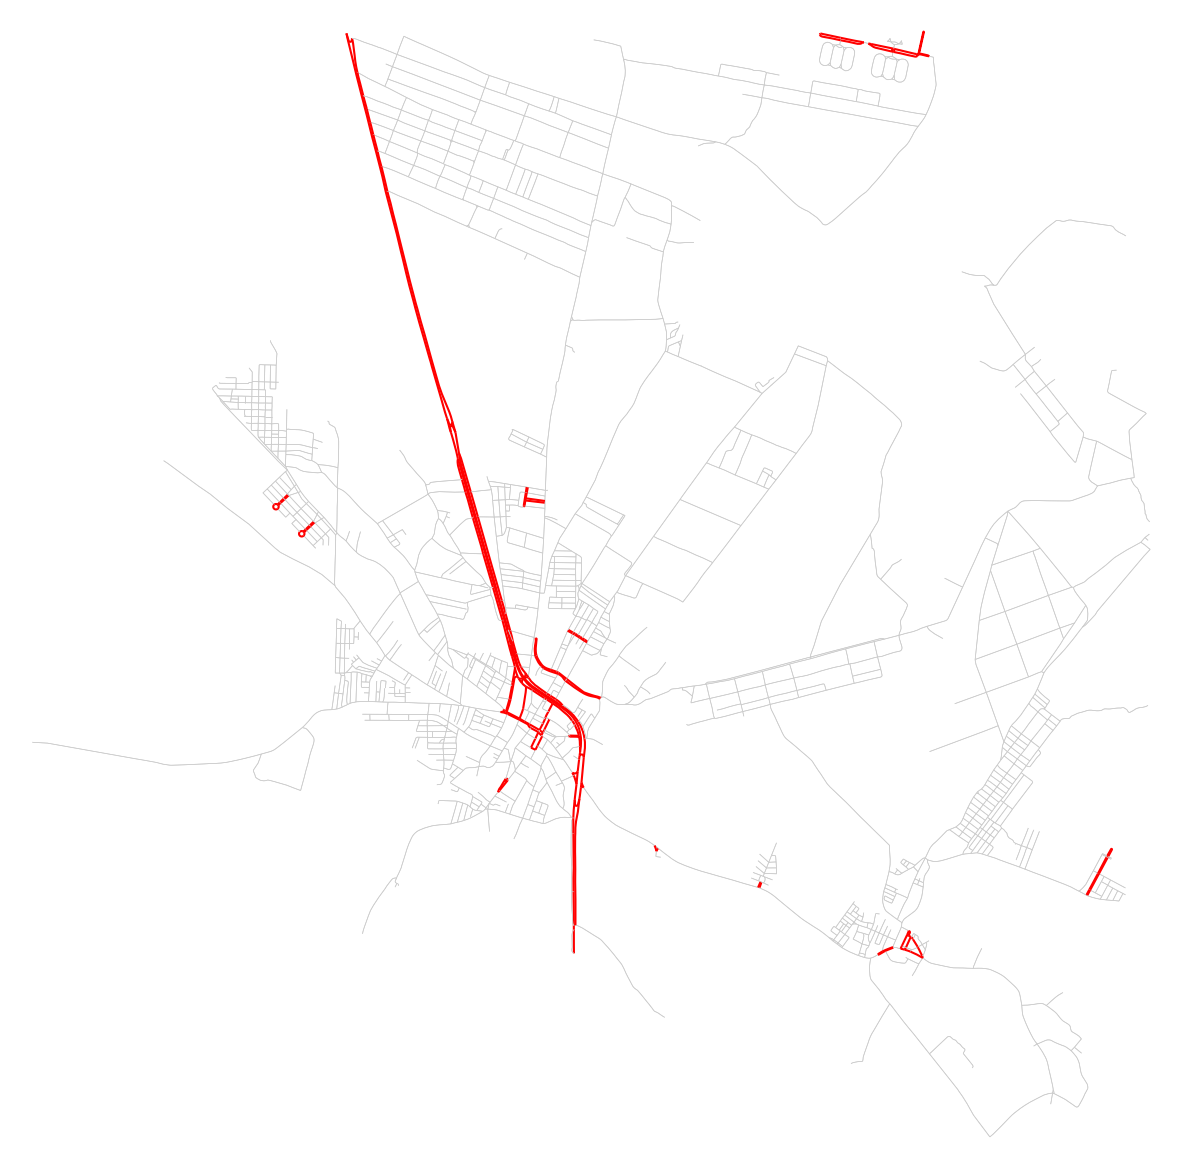

In [35]:
# Analisando a direção: destacando vias de mão única (oneway)
# O OSMnx guarda essa informação no atributo 'oneway' de cada aresta
cores_arestas = ['red' if data.get('oneway') else '#cccccc' for u, v, key, data in G.edges(keys=True, data=True)]
espessura_arestas = [1.5 if data.get('oneway') else 0.5 for u, v, key, data in G.edges(keys=True, data=True)]

print("Vias em VERMELHO são de mão única (fluxo direcionado assimétrico).")
print("Vias em CINZA são de mão dupla (fluxo bidirecional simétrico).")

fig, ax = ox.plot.plot_graph(G,
                             figsize=(15, 15),
                             node_size=0, # Escondemos os nós para focar no traçado
                             edge_linewidth=espessura_arestas,
                             bgcolor='white',
                             edge_color=cores_arestas
                             )

Pesos (Distâncias)

Mapa de Pesos: Cores mais claras indicam trechos viários mais longos sem interrupções (cruzamentos).


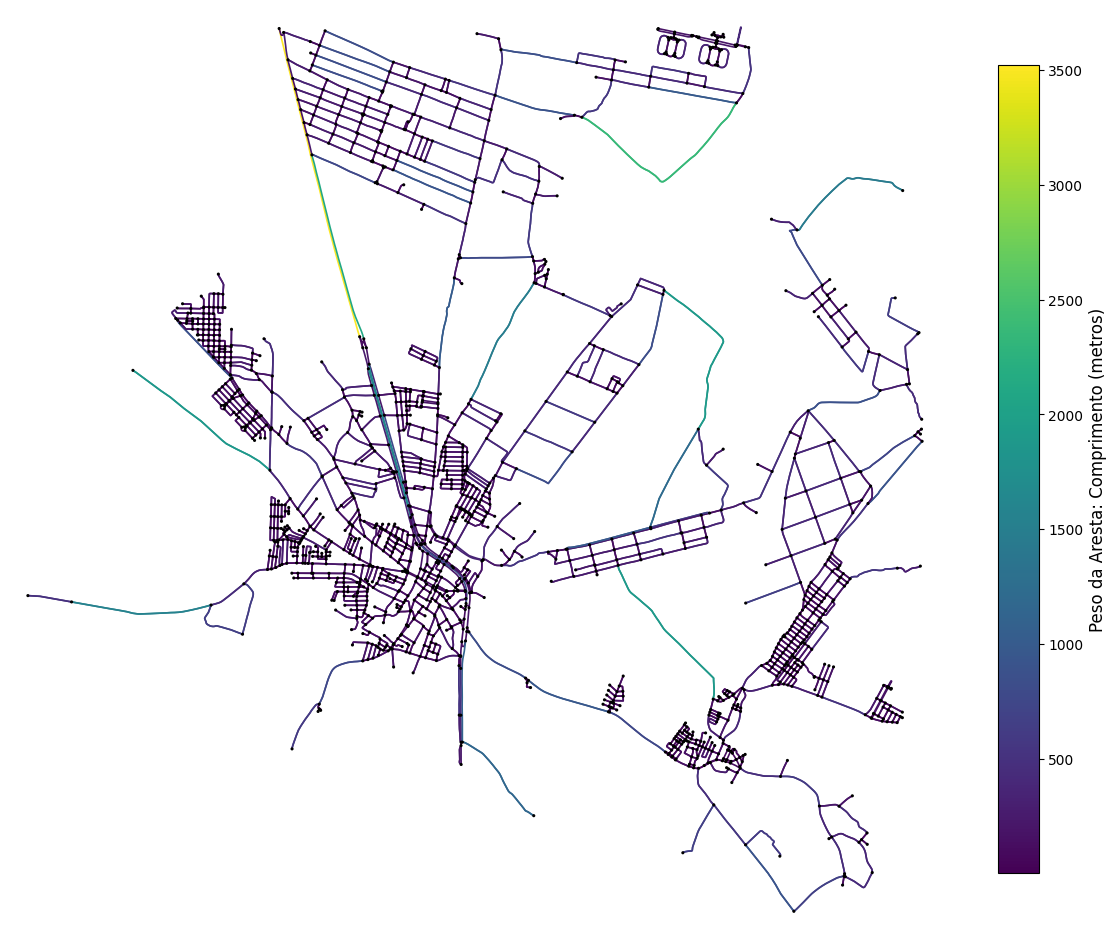

In [36]:
# Extraindo os pesos (comprimento em metros) de cada aresta
comprimentos = [data.get('length', 0) for u, v, key, data in G.edges(keys=True, data=True)]

# Criando um mapa de cores (ruas curtas = roxo/azul, ruas longas = amarelo/verde)
norm = mcolors.Normalize(vmin=min(comprimentos), vmax=max(comprimentos))
cmap = cm.viridis
cores_pesos = [cmap(norm(comp)) for comp in comprimentos]

print("Mapa de Pesos: Cores mais claras indicam trechos viários mais longos sem interrupções (cruzamentos).")

fig, ax = ox.plot.plot_graph(G,
                             figsize=(15, 15),
                             node_size=5,
                             node_color='black',
                             edge_linewidth=1.2,
                             edge_color=cores_pesos,
                             bgcolor='white',
                             show=False, # Seguramos a imagem para adicionar a barra lateral
                             close=False)

# Adicionando a barra de escala para facilitar a leitura dos pesos
cbar = plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.7)
cbar.set_label('Peso da Aresta: Comprimento (metros)', fontsize=12)

plt.show()

Medições

In [37]:
# what sized area does our network cover in square meters?
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
print(f"{graph_area_m:.2f} m")
# show some basic stats about the network
ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)

71136271.95 m


{'n': 1585,
 'm': 4357,
 'k_avg': 5.497791798107255,
 'edge_length_total': 565420.9279091319,
 'edge_length_avg': 129.7729924051255,
 'streets_per_node_avg': 2.938801261829653,
 'streets_per_node_counts': {0: 0, 1: 184, 2: 0, 3: 1130, 4: 271},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.11608832807570978,
  2: 0.0,
  3: 0.7129337539432177,
  4: 0.17097791798107256},
 'intersection_count': 1401,
 'street_length_total': 300175.5736624162,
 'street_segment_count': 2313,
 'street_length_avg': 129.77759345543285,
 'circuity_avg': 1.03990608125173,
 'self_loop_proportion': 0.00043233895373973193,
 'clean_intersection_count': 1084,
 'node_density_km': 22.281178878543958,
 'intersection_density_km': 19.69459407497797,
 'edge_density_km': 7948.419455151845,
 'street_density_km': 4219.7259632440655,
 'clean_intersection_density_km': 15.23835829926918}

In [38]:
# Pegando o grau de cada nó (cruzamento)
graus = dict(G.degree())

# Ordenando para encontrar os Hubs (os cruzamentos com mais vias conectadas)
hubs = sorted(graus.items(), key=lambda item: item[1], reverse=True)

print("Top 5 Hubs (ID do nó, Grau):")
for no, grau in hubs[:5]:
    print(f"Nó: {no} | Grau: {grau}")

Top 5 Hubs (ID do nó, Grau):
Nó: 1371092853 | Grau: 8
Nó: 1371092880 | Grau: 8
Nó: 1371092882 | Grau: 8
Nó: 1993248242 | Grau: 8
Nó: 1999502191 | Grau: 8


In [39]:
# Centralidades para navegação e fluxo das ruas

# Grau (conectividade)
degree = nx.degree_centrality(G)
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)

# Closeness Centrality (Quão perto um nó está de todos os outros)
# O NetworkX usa 'distance' para calcular o caminho mais curto
closeness = nx.closeness_centrality(G, distance="length")

# Harmonic Centrality (acessibilidade robusta a componentes desconectados)
harmonic = nx.harmonic_centrality(G, distance="length")

# Betweenness Centrality (Quais nós servem como "pontes" para o fluxo)
# Atenção: Essa métrica é a mais "pesada" para o processador, pode levar alguns segundos.
betweenness = nx.betweenness_centrality(G, weight="length")

# Edge Betweenness (vias/trechos que concentram fluxo)
# Atenção: Pode levar alguns segundos em grafos maiores.
edge_betweenness = nx.edge_betweenness_centrality(G, weight="length")

# PageRank (importância topológica no fluxo)
pagerank = nx.pagerank(G)

print("Centralidades calculadas com sucesso!")

Centralidades calculadas com sucesso!


Gerando o mapa de calor da centralidade...


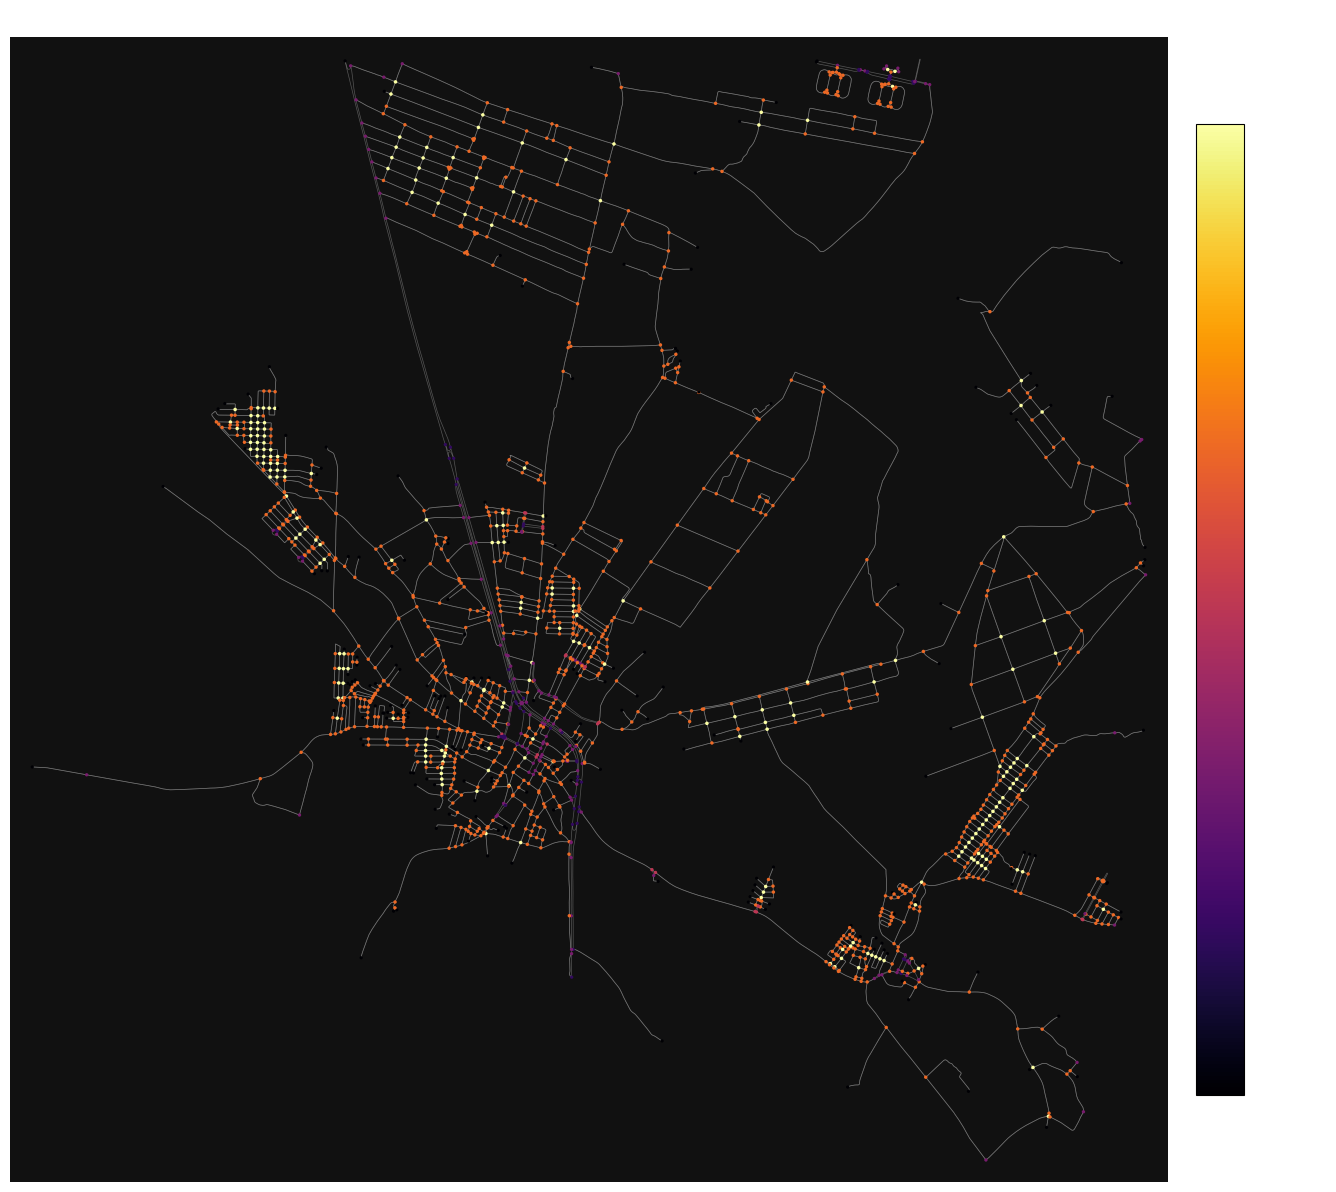

In [40]:
# =====================================================================
# Escolha da centralidade para o mapa de calor
centralidades = {
    "degree": degree,
    "in_degree": in_degree,
    "out_degree": out_degree,
    "closeness": closeness,
    "harmonic": harmonic,
    "betweenness": betweenness,
    "edge_betweenness": edge_betweenness,
    "pagerank": pagerank,
}
nome_centralidade = "degree"
dicionario_centralidade = centralidades[nome_centralidade]
# =====================================================================

# 2. Extrair os valores na exata ordem dos nós do grafo
valores_nos = [dicionario_centralidade[no] for no in G.nodes()]

# 3. Configurar o Mapa de Cores (Colormap)
# 'plasma' ou 'inferno' são ótimos para mapas de calor noturnos/escuros
# 'viridis' ou 'coolwarm' funcionam bem em fundos claros
cmap = cm.inferno
norm = mcolors.Normalize(vmin=min(valores_nos), vmax=max(valores_nos))
cores_dos_nos = [cmap(norm(valor)) for valor in valores_nos]

# 4. (Opcional) Fazer o tamanho do nó variar com a centralidade
# Multiplicamos por um fator (ex: 300) para que o nó fique visível.
# Somamos um valor base (ex: 5) para que os nós com centralidade zero não sumam.
tamanhos_dos_nos = [(valor * 300) + 5 for valor in valores_nos]

print("Gerando o mapa de calor da centralidade...")

# 5. Plotar o Grafo
fig, ax = ox.plot.plot_graph(G,
                             figsize=(18, 18),
                             node_size=tamanhos_dos_nos, # Tamanho dinâmico
                             node_color=cores_dos_nos,   # Cor dinâmica
                             node_edgecolor='none',      # Remove a borda do nó para ficar mais limpo
                             node_zorder=3,              # Garante que os nós fiquem por cima das linhas
                             edge_color='#999999',       # Ruas em cinza claro para não ofuscar os nós
                             edge_linewidth=0.5,
                             edge_alpha=0.5,             # Deixa as ruas levemente transparentes
                             bgcolor='#111111',          # Fundo escuro realça mapas de calor
                             show=False, 
                             close=False)

# 6. Adicionar a barra de cores (Legenda)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Valor da Centralidade', color='white', fontsize=14)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white') # Ajusta a cor dos números da legenda

titulo = f"Mapa de Calor de {nome_centralidade.replace('_', ' ').title()}"
plt.title(titulo, color='white', fontsize=18)
plt.show()

In [41]:
# Convertendo para um grafo simples e não-direcionado para análise de K-core
G_undirected = ox.convert.to_undirected(G)
G_simples = nx.Graph(G_undirected)

# Removendo auto-lacos (self-loops) que impedem o K-core
G_simples.remove_edges_from(nx.selfloop_edges(G_simples))

# Calculando o core number de cada nó
core_numbers = nx.core_number(G_simples)

# Extraindo apenas o subgrafo principal (o core máximo)
k_maximo = max(core_numbers.values())
k_core_graph = nx.k_core(G_simples, k=k_maximo)

print(f"O K-core máximo desta rede é: {k_maximo}")
print(f"Número de nós no K-core principal: {k_core_graph.number_of_nodes()}")

O K-core máximo desta rede é: 2
Número de nós no K-core principal: 1376
